In [16]:
import random
from pathlib import Path
import math

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, metrics, models, optimizers, activations, losses

import torch
from torch.utils.data import Dataset
from torchvision import transforms
import torchvision.datasets as dsets
from torchvision.datasets import GTSRB

from google.colab import files, output, runtime

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch version: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA L4


In [2]:
RAW_DIR       = "./data/raw"        # Where raw GTSRB data is downloaded
PROCESSED_DIR = "./data/processed"  # Where cleaned images are saved
IMAGE_SIZE      = 64                  # Output resolution (64 or 128 recommended)
BATCH_SIZE    = 32                  # DataLoader batch size
SEED          = 42                  # Reproducibility
DATASET_REPETITIONS = 1
EPOCHS = 20
EMA = 0.999
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
NOISE_EMBEDDING_SIZE = 32

random.seed(SEED)
torch.manual_seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [3]:
train_dataset = GTSRB(root=RAW_DIR, split="train", download=True)

min_dim = 64

eligible_indices = []
for idx in range(len(train_dataset)):
    pil_img, _ = train_dataset[idx]
    if min(pil_img.size) >= min_dim:
        eligible_indices.append(idx)

sample_count = min(100, len(eligible_indices))
sample_indices = random.sample(eligible_indices, sample_count)

print(f"Total eligible images: {len(eligible_indices)}")

def preprocess_gtsrb_image(pil_img):
    img = pil_img.convert("RGB")
    img = ImageOps.fit(
        img,
        (IMAGE_SIZE, IMAGE_SIZE),
        method=Image.Resampling.LANCZOS,
        centering=(0.5, 0.5),
    )
    return np.asarray(img, dtype=np.float32) / 255.0

sampled_images = []
for idx in sample_indices:
    pil_img, _ = train_dataset[idx]
    sampled_images.append(preprocess_gtsrb_image(pil_img))

sampled_images = np.stack(sampled_images, axis=0)

train = tf.data.Dataset.from_tensor_slices(sampled_images)
train = train.shuffle(200, seed=SEED)
train = train.batch(BATCH_SIZE, drop_remainder=False)
train = train.prefetch(tf.data.AUTOTUNE)
train = train.repeat(DATASET_REPETITIONS)

100%|██████████| 187M/187M [00:18<00:00, 10.4MB/s]


Total eligible images: 4771


In [4]:
def offset_cosine_diffusion_schedule(diffusion_times):
    min_signal_rate = 0.02
    max_signal_rate = 0.95
    start_angle = tf.acos(max_signal_rate)
    end_angle = tf.acos(min_signal_rate)

    diffusion_angles = start_angle + diffusion_times * (end_angle - start_angle)

    signal_rates = tf.cos(diffusion_angles)
    noise_rates = tf.sin(diffusion_angles)

    return noise_rates, signal_rates

@tf.keras.utils.register_keras_serializable()
def sinusoidal_embedding(x):
    frequencies = tf.exp(tf.linspace( tf.math.log(1.0), tf.math.log(1000.0), NOISE_EMBEDDING_SIZE // 2))
    angular_speeds = 2.0 * math.pi * frequencies
    embeddings = tf.concat([tf.sin(angular_speeds * x), tf.cos(angular_speeds * x)], axis=3)
    return embeddings

def ResidualBlock(width):
    def apply(x):
        input_width = x.shape[3]
        if input_width == width:
            residual = x
        else:
            residual = layers.Conv2D(width, kernel_size=1)(x)
        x = layers.BatchNormalization(center=False, scale=False)(x)
        x = layers.Conv2D(width, kernel_size=3, padding="same", activation=activations.swish)(x)
        x = layers.Conv2D(width, kernel_size=3, padding="same")(x)
        x = layers.Add()([x, residual])
        return x

    return apply

def DownBlock(width, block_depth):
    def apply(x):
        x, skips = x
        for _ in range(block_depth):
            x = ResidualBlock(width)(x)
            skips.append(x)
        x = layers.AveragePooling2D(pool_size=2)(x)
        return x

    return apply

def UpBlock(width, block_depth):
    def apply(x):
        x, skips = x
        x = layers.UpSampling2D(size=2, interpolation="bilinear")(x)
        for _ in range(block_depth):
            x = layers.Concatenate()([x, skips.pop()])
            x = ResidualBlock(width)(x)
        return x
    return apply

In [5]:
noisy_images = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
x = layers.Conv2D(32, kernel_size=1)(noisy_images)

noise_variances = layers.Input(shape=(1, 1, 1))
noise_embedding = layers.Lambda(sinusoidal_embedding, output_shape=(1, 1, NOISE_EMBEDDING_SIZE))(noise_variances)
noise_embedding = layers.UpSampling2D(size=IMAGE_SIZE, interpolation="nearest")(noise_embedding)

x = layers.Concatenate()([x, noise_embedding])

skips = []
x = DownBlock(32, block_depth=2)([x, skips])
x = DownBlock(64, block_depth=2)([x, skips])
x = DownBlock(96, block_depth=2)([x, skips])
x = ResidualBlock(128)(x)
x = ResidualBlock(128)(x)
x = UpBlock(96, block_depth=2)([x, skips])
x = UpBlock(64, block_depth=2)([x, skips])
x = UpBlock(32, block_depth=2)([x, skips])
x = layers.Conv2D(3, kernel_size=1, kernel_initializer="zeros")(x)
unet = models.Model([noisy_images, noise_variances], x, name="unet")

In [6]:
class DiffusionModel(models.Model):
    def __init__(self):
        super().__init__()

        self.normalizer = layers.Normalization()
        self.network = unet
        self.ema_network = models.clone_model(self.network)
        self.diffusion_schedule = offset_cosine_diffusion_schedule

    def build(self, input_shape):
        dummy_images = tf.zeros((1, IMAGE_SIZE, IMAGE_SIZE, 3))
        dummy_noise = tf.zeros((1, 1, 1, 1))
        _ = self.network([dummy_images, dummy_noise])
        _ = self.ema_network([dummy_images, dummy_noise])
        super().build(input_shape)

    def compile(self, **kwargs):
        super().compile(**kwargs)
        self.noise_loss_tracker = metrics.Mean(name="n_loss")

    @property
    def metrics(self):
        return [self.noise_loss_tracker]

    def denormalize(self, images):
        images = self.normalizer.mean + images * self.normalizer.variance**0.5
        return tf.clip_by_value(images, 0.0, 1.0)

    def denoise(self, noisy_images, noise_rates, signal_rates, training):
        if training:
            network = self.network
        else:
            network = self.ema_network
        pred_noises = network([noisy_images, noise_rates**2], training=training)
        pred_images = (noisy_images - noise_rates * pred_noises) / signal_rates
        return pred_noises, pred_images

    def train_step(self, images):
        images = self.normalizer(images, training=True)
        batch_size = tf.shape(images)[0]
        noises = tf.random.normal(shape=(batch_size, IMAGE_SIZE, IMAGE_SIZE, 3))

        diffusion_times = tf.random.uniform(shape=(batch_size, 1, 1, 1), minval=0.0, maxval=1.0)
        noise_rates, signal_rates = self.diffusion_schedule(diffusion_times)
        noisy_images = signal_rates * images + noise_rates * noises

        with tf.GradientTape() as tape:
            pred_noises, pred_images = self.denoise(noisy_images, noise_rates, signal_rates, training=True)
            noise_loss = self.loss(noises, pred_noises)

        gradients = tape.gradient(noise_loss, self.network.trainable_weights)
        self.optimizer.apply_gradients(zip(gradients, self.network.trainable_weights))
        self.noise_loss_tracker.update_state(noise_loss)

        for weight, ema_weight in zip(self.network.weights, self.ema_network.weights):
            ema_weight.assign(EMA * ema_weight + (1 - EMA) * weight)

        return {m.name: m.result() for m in self.metrics}

    def test_step(self, images):
        images = self.normalizer(images, training=False)
        batch_size = tf.shape(images)[0]
        noises = tf.random.normal(shape=(batch_size, IMAGE_SIZE, IMAGE_SIZE, 3))
        diffusion_times = tf.random.uniform(shape=(batch_size, 1, 1, 1), minval=0.0, maxval=1.0)
        noise_rates, signal_rates = self.diffusion_schedule(diffusion_times)
        noisy_images = signal_rates * images + noise_rates * noises
        pred_noises, pred_images = self.denoise(noisy_images, noise_rates, signal_rates, training=False)
        noise_loss = self.loss(noises, pred_noises)
        self.noise_loss_tracker.update_state(noise_loss)
        return {m.name: m.result() for m in self.metrics}

    def generate(self, num_images, diffusion_steps, initial_noise=None):
        if initial_noise is None:
            initial_noise = tf.random.normal(shape=(num_images, IMAGE_SIZE, IMAGE_SIZE, 3))
        generated_images = self.reverse_diffusion(initial_noise, diffusion_steps)
        generated_images = self.denormalize(generated_images)
        return generated_images

    def reverse_diffusion(self, initial_noise, diffusion_steps):
        num_images = initial_noise.shape[0]
        step_size = 1.0 / diffusion_steps
        current_images = initial_noise
        for step in range(diffusion_steps):
            diffusion_times = tf.ones((num_images, 1, 1, 1)) - step * step_size
            noise_rates, signal_rates = self.diffusion_schedule(diffusion_times)
            pred_noises, pred_images = self.denoise(current_images, noise_rates, signal_rates, training=False)
            next_diffusion_times = diffusion_times - step_size
            next_noise_rates, next_signal_rates = self.diffusion_schedule(next_diffusion_times)
            current_images = (next_signal_rates * pred_images + next_noise_rates * pred_noises)
        return pred_images

adamw = optimizers.AdamW(
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY)

In [7]:
diffusion_model = DiffusionModel()

diffusion_model.normalizer.adapt(train)

diffusion_model.compile(optimizer=adamw, loss=losses.MeanAbsoluteError())

diffusion_model.build((None, IMAGE_SIZE, IMAGE_SIZE, 3))

checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath='weights/epoch_{epoch:03d}.weights.h5',
    save_weights_only=True,
)

history = diffusion_model.fit(train, epochs=EPOCHS, callbacks=[checkpoint_cb])

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 50s 6s/step - n_loss: 0.7970
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 183ms/step - n_loss: 0.7972
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 186ms/step - n_loss: 0.7945
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 183ms/step - n_loss: 0.7902
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 187ms/step - n_loss: 0.7872
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 189ms/step - n_loss: 0.7822
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 185ms/step - n_loss: 0.7759
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 186ms/step - n_loss: 0.7677
Epoch 9/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 187ms/step - n_loss: 0.7590
Epoch 10/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 186ms/step - n_loss: 0.7476
Epoch 11/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 185ms/step - n_loss: 0.7316
Epoch 12/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 184ms/step - n_loss: 0.7199
Epoch 13/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 190ms/step - n_loss: 0.7038
Epoch 14/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 186ms/step - n_loss: 0.6918
Epoch 15/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 186ms/step - n_loss

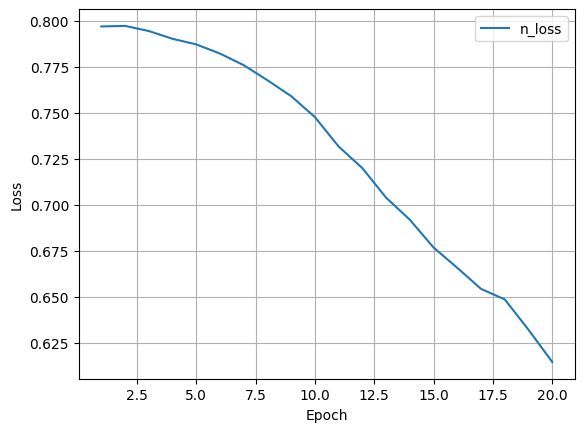

In [9]:
n_loss = history.history.get('n_loss', [])
epochs = range(1, len(n_loss) + 1)
plt.plot(epochs, n_loss, label='n_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
!zip -r /content/weights.zip /content/weights

  adding: content/weights/ (stored 0%)
  adding: content/weights/epoch_007.weights.h5 (deflated 9%)
  adding: content/weights/epoch_010.weights.h5 (deflated 9%)
  adding: content/weights/epoch_018.weights.h5 (deflated 9%)
  adding: content/weights/epoch_014.weights.h5


zip error: Interrupted (aborting)


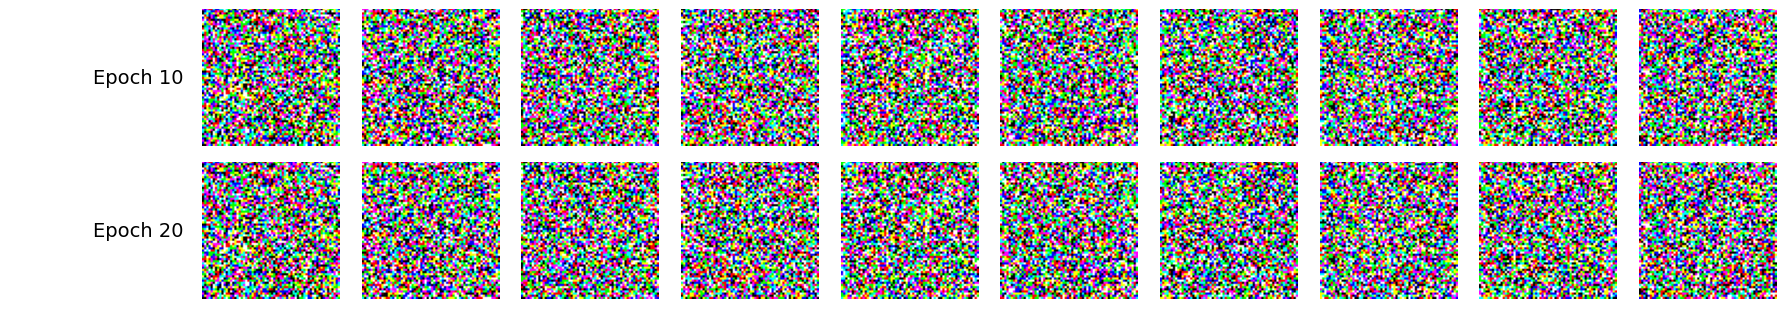

Loaded 2 checkpoints from weights
Saved grid to data/processed/epoch_grids_after_training/diffusion_steps_100_epoch_grid.png


In [10]:
from pathlib import Path
import re

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

NUM_IMAGES = 10
DIFFUSION_STEPS = 100
SEED = 42

EPOCH_RANGE = (10, 20, 10)

np.random.seed(SEED)
tf.random.set_seed(SEED)

checkpoint_dirs = [Path("./checkpoints"), Path("./weights"), Path("./data/processed/weights")]
checkpoint_patterns = ["diffusion_weights_epoch*.h5", "epoch_*.weights.h5"]

weights_dir = None
epoch_path_pairs = []

for candidate_dir in checkpoint_dirs:
    if not candidate_dir.exists():
        continue

    matches = []
    for pattern in checkpoint_patterns:
        matches.extend(candidate_dir.glob(pattern))

    if not matches:
        continue

    weights_dir = candidate_dir

    for p in matches:
        m = re.search(r"epoch[_-]?(\d+)", p.name)
        if m:
            epoch_path_pairs.append((int(m.group(1)), p))

    if not epoch_path_pairs:
        for p in matches:
            m2 = re.search(r"(\d{2,4})", p.name)
            if m2:
                epoch_path_pairs.append((int(m2.group(1)), p))

    if not epoch_path_pairs:
        raise FileNotFoundError(
            f"No checkpoint filenames contain an epoch number. Matches: {[p.name for p in matches]}"
        )

    epoch_path_pairs.sort(key=lambda x: x[0])
    break

if not epoch_path_pairs:
    raise FileNotFoundError("No saved weights found.")

available_epochs = [ep for ep, _ in epoch_path_pairs]

if EPOCH_RANGE is not None:
    start, end, step = EPOCH_RANGE
    epoch_path_pairs = [(ep, p) for ep, p in epoch_path_pairs if start <= ep <= end and (ep - start) % step == 0]

if not epoch_path_pairs:
    raise ValueError(f"No checkpoints left after filtering. Available epochs: {available_epochs}")

base_noise = tf.random.normal(shape=(NUM_IMAGES, IMAGE_SIZE, IMAGE_SIZE, 3), seed=SEED)
out_dir = Path("./data/processed") / "epoch_grids"
out_dir.mkdir(parents=True, exist_ok=True)

fig = plt.figure(figsize=(NUM_IMAGES * 1.6 + 2.0, len(epoch_path_pairs) * 1.6))
gs = fig.add_gridspec(len(epoch_path_pairs), NUM_IMAGES + 1, width_ratios=[1.2] + [1] * NUM_IMAGES)

model = DiffusionModel()
model.build((None, IMAGE_SIZE, IMAGE_SIZE, 3))
model.normalizer.build((None, IMAGE_SIZE, IMAGE_SIZE, 3))

loaded_count = 0

for row_index, (epoch_number, weight_path) in enumerate(epoch_path_pairs):
    try:
        model.load_weights(str(weight_path))
    except Exception as e:
        print(f"Skipping {weight_path.name}: {e}")
        continue

    generated = model.generate(NUM_IMAGES, DIFFUSION_STEPS, initial_noise=base_noise).numpy()
    loaded_count += 1

    ax_label = fig.add_subplot(gs[row_index, 0])
    ax_label.axis("off")
    ax_label.text(1.0, 0.5, f"Epoch {epoch_number}", ha="right", va="center", fontsize=14)

    for col_index in range(NUM_IMAGES):
        ax = fig.add_subplot(gs[row_index, col_index + 1])
        ax.imshow(np.clip(generated[col_index], 0.0, 1.0))
        ax.axis("off")

plt.tight_layout()
save_path = out_dir / f"ds_{DIFFUSION_STEPS}_dim_{IMAGE_SIZE}_epoch_grid.png"
fig.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()



print(f"Loaded {loaded_count} checkpoints from {weights_dir}")
print(f"Saved grid to {save_path}")

In [17]:
files.download(save_path)
files.download('/content/weights.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
output.eval_js('new Audio("https://upload.wikimedia.org/wikipedia/commons/0/05/Beep-09.ogg").play()')

In [ ]:
runtime.unassign()